In [52]:
import gspread
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.oauth2.service_account import Credentials

from wordcloud import WordCloud, ImageColorGenerator
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import seaborn as sns

In [2]:
SERVICE_ACCOUNT_FILE = '../../key/Credentials.json'
SCOPES = ['https://www.googleapis.com/auth/spreadsheets',
          'https://www.googleapis.com/auth/drive']

creds = Credentials.from_service_account_file(SERVICE_ACCOUNT_FILE, scopes=SCOPES)
client = gspread.authorize(creds)

sheet = client.open('AI Summary Tagging').worksheet("AI Summary")
data = sheet.get_all_values()

df = pd.DataFrame(data[2:], columns=data[1])
df.to_csv('../../raw_data/ai_summary.csv', index=False)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13802 entries, 0 to 13801
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   No                           13802 non-null  object
 1   Tanggal Pengerjaan           13802 non-null  object
 2   Checker                      13802 non-null  object
 3   ASI/AFI                      13802 non-null  object
 4   Nama Agent                   13802 non-null  object
 5   ID Ticket                    13802 non-null  object
 6   Summary Avail                13802 non-null  object
 7   Case Status                  13802 non-null  object
 8   Waktu Chat                   13802 non-null  object
 9   Sentimen Pengguna            13802 non-null  object
 10  Revisi Sentimen              13802 non-null  object
 11  Masalah Pelanggan            13802 non-null  object
 12  Solusi                       13802 non-null  object
 13  Perselisihan                 13

In [31]:
df_clean = (
    df.copy()
    .drop(columns=['No'])
    .rename(columns=lambda x: x.strip().lower())
    .rename(columns=lambda x: x.replace(' ', '_'))
    .apply(lambda x: x.str.strip().str.lower() if x.dtype == 'object' else x)
)

df_clean = df_clean[df_clean['revisi_sentimen'] == 'negatif']
df_clean

,tanggal_pengerjaan,checker,asi/afi,nama_agent,id_ticket,summary_avail,case_status,waktu_chat,sentimen_pengguna,revisi_sentimen,masalah_pelanggan,solusi,perselisihan,apakah_sudah_terselesaikan?,hasil_summary,alasan_tidak_suka,nama_sampling
297,07/22/2025,azer,afi,silvia puspitasari,20324885,,,2025-07-12 07:20:54,netral,negatif,benar,benar,benar,benar,bad,sentimen pengguna seharusnya 'negatif' dikaren...,
436,07/23/2025,neneng,afi,dwi jalu febriyadi,20366091,,,2025-07-15 00:00:39,netral,negatif,salah,benar,benar,benar,bad,"sentimen pengguna seharusnya ""negatif"" karena ...",
449,07/23/2025,neneng,afi,elfina rahmawati,20268626,,,2025-07-08 18:51:16,netral,negatif,salah,benar,benar,benar,bad,"sentimen pengguna seharusnya ""negatif"" karena ...",
469,07/23/2025,azer,asi,rizaldi ardin wicaksono,20163878,,,2025-07-05 15:43:22,positif,negatif,salah,benar,benar,benar,bad,seharusnya sentimen pengguna negatif dikarenak...,
472,07/23/2025,azer,asi,rizaldi ardin wicaksono,20205315,,,2025-07-06 16:14:25,netral,negatif,benar,benar,benar,benar,bad,sentimen pengguna seharusnya negatif dikarenak...,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13787,03/09/2026,reza,asi,wilmar ruchi dewantara,23145109,,close,2026-03-03 23:07:04,netral,negatif,benar,benar,,,bad,seharusnya sentimen negatif karena pengguna ad...,
13789,03/09/2026,reza,asi,wilmar ruchi dewantara,23145338,,close,2026-03-03 23:38:36,netral,negatif,benar,benar,,,bad,seharusnya sentimen negatif karena pengguna ad...,
13790,03/09/2026,reza,asi,wilmar ruchi dewantara,23145338,,close,2026-03-03 23:39:45,netral,negatif,benar,benar,,,bad,seharusnya sentimen negatif karena pengguna ad...,
13793,03/09/2026,reza,asi,wilmar ruchi dewantara,23180585,,close,2026-03-09 09:20:02,netral,negatif,benar,benar,,,bad,seharusnya sentimen negatif karena pengguna ad...,


In [36]:
word_string = ' '.join(df_clean['alasan_tidak_suka'].str.lower())
word_string

'sentimen pengguna seharusnya \'negatif\' dikarenakan cust mengeluhkan sudah bayar tapi di aplikasinya tidak berubah sentimen pengguna seharusnya "negatif" karena  user komplain terkait pembayaran dan komplain pengguna seharusnya seharusnya komplain bukan bertanya sentimen pengguna seharusnya "negatif" karena  user komplain terkait nama yang tidak berubah pada aplikasi seharusnya sentimen pengguna negatif dikarenakan user mengeluhkan ada yg belum di proses sentimen pengguna seharusnya negatif dikarenakan user mengeluh tidak bisa transakdi cicilan sentimen pengguna seharusnya negatif dikarenakan use mengelih pembayaran tagihan pinjaman belum masuk (over estimasi) sentimen pada kesimpulan obrolan kula ini seharusnya negatif, karena pada percakapan user mengucapkan keluhannya terkait sudah bayar tagihan pinjaman, tetapi masih muncul. sentimen pada kesimpulan obrolan kula ini seharusnya negatif, karena user mengeluhkan  pembayaran paylater via ovo di hari kamis pukul 21:45 tapi pembayaran 

(np.float64(-0.5), np.float64(899.5), np.float64(899.5), np.float64(-0.5))

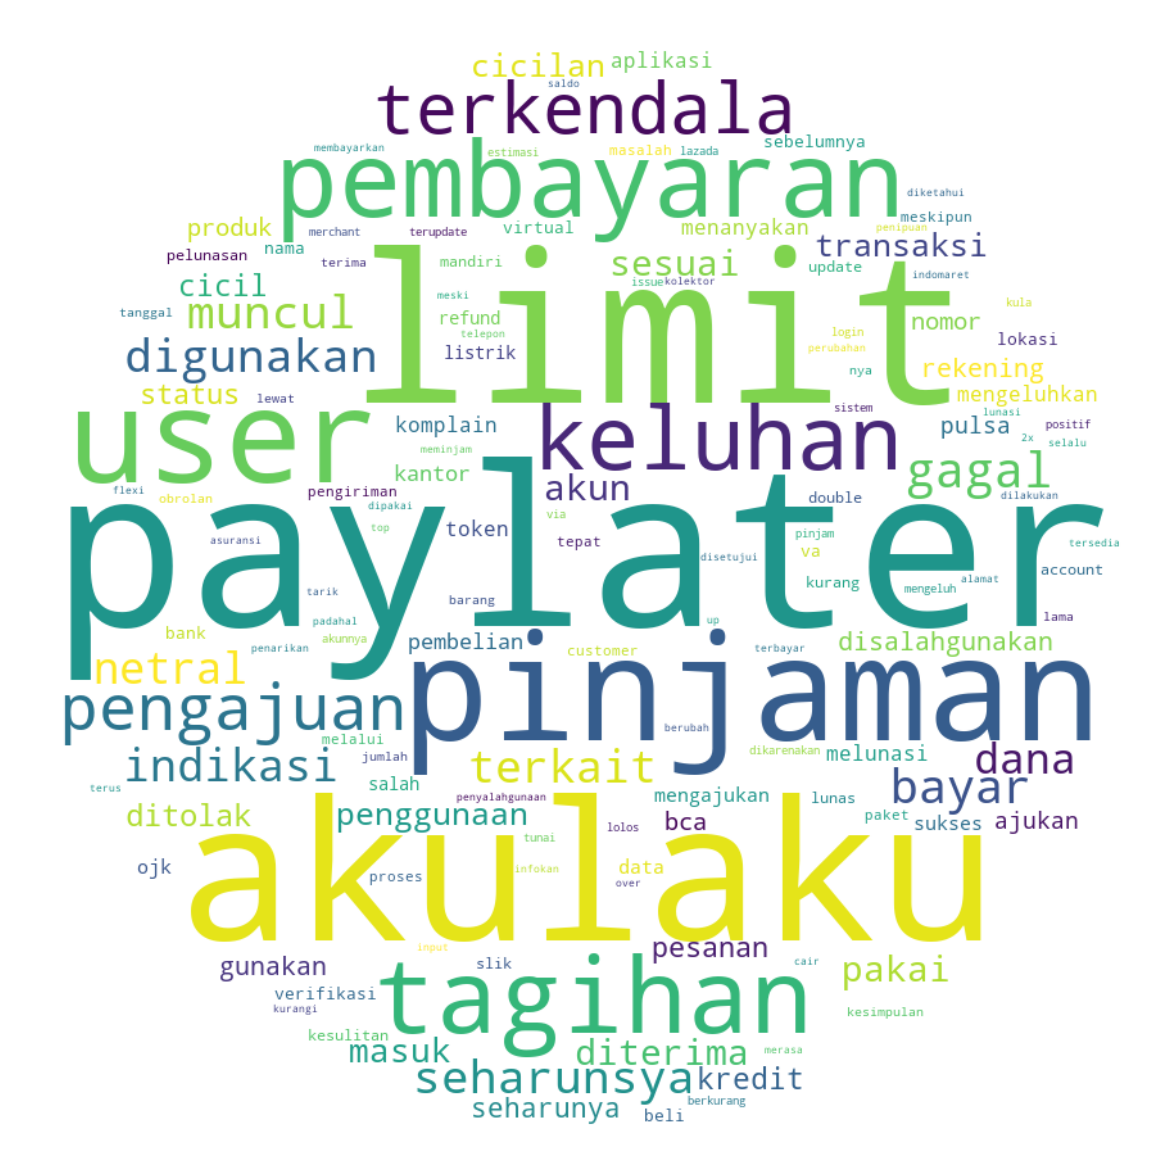

In [70]:
factory = StopWordRemoverFactory()
stopwords = set(factory.get_stop_words())

custom_stopwords = {
    'pengguna', 'mengalami', 'pengguna mengalami', 'sentimen', 'sentimen negatif', 'negatif', 'terdapat kendala', 'terdapat', 'kendala', 'menggunakan', 'melakukan'
}

stopwords = stopwords.union(custom_stopwords)

# mask
size = 900
x, y = np.ogrid[:size, :size]
center = size // 2
radius = size // 2 - 20

mask = ((x - center) ** 2 + (y - center) ** 2 > radius ** 2).astype(np.uint8) * 255

plt.figure(figsize=(15,15))

# wordcloud
wc = WordCloud(
    background_color='white',
    stopwords=stopwords,
    mask=mask,
    max_words=500,
    max_font_size=220,
    min_font_size=8,
    width=size,
    height=size,
    prefer_horizontal=1.0,
    collocations=False,
    colormap='Set1',   # bisa ganti: tab10, Set1, Dark2, turbo
    random_state=42
).generate(word_string)

plt.imshow(wc.recolor(colormap='viridis', random_state=17), interpolation='bilinear')
plt.axis('off')